In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import re
from fake_useragent import UserAgent
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import time
from xgboost import XGBClassifier


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [24]:
train = pd.read_csv('train_p.csv')
test = pd.read_csv('test_p.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (105000, 12)
Test shape: (45000, 11)


In [25]:
train.head(50)

,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs
0,9580,0.668999,58,2,0.449504,3425.0,9,1,1,1,1.0,0
1,39755,0.015922,71,0,6.000000,NaN,5,0,0,0,0.0,0
2,118799,0.183062,52,1,0.035593,5000.0,9,0,0,0,0.0,0
3,16489,0.162301,77,0,0.227886,2000.0,8,0,0,0,0.0,0
4,149857,0.404199,30,0,0.026010,5843.0,4,0,0,0,0.0,0
5,6660,0.041418,80,0,0.003936,10416.0,4,0,0,0,0.0,0
6,78173,0.049883,60,0,1365.000000,NaN,7,0,1,0,3.0,0
7,137509,0.000547,68,0,0.149124,6450.0,7,0,1,0,0.0,0
8,4629,0.082170,38,0,1.154338,2500.0,5,0,1,0,0.0,0
9,21512,0.043415,65,0,0.008374,3701.0,2,0,0,0,1.0,0


In [26]:
print(train.isnull().sum())
print(train.dtypes)




ID                                          0
RevolvingUtilizationOfUnsecuredLines        0
Age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           20836
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       2764
SeriousDlqin2yrs                            0
dtype: int64
ID                                        int64
RevolvingUtilizationOfUnsecuredLines    float64
Age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
Num

In [27]:
print(test.isnull().sum())
print(test.dtypes)

ID                                         0
RevolvingUtilizationOfUnsecuredLines       0
Age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                           8895
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                      1160
dtype: int64
ID                                        int64
RevolvingUtilizationOfUnsecuredLines    float64
Age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDepe

In [28]:
train['MonthlyIncome_missing'] = train['MonthlyIncome'].isnull().astype(int)
test['MonthlyIncome_missing'] = test['MonthlyIncome'].isnull().astype(int)

train['NumberOfDependents_missing'] = train['NumberOfDependents'].isnull().astype(int)
test['NumberOfDependents_missing'] = test['NumberOfDependents'].isnull().astype(int)

train['MonthlyIncome'] = train['MonthlyIncome'].fillna(train['MonthlyIncome'].median())
test['MonthlyIncome'] = test['MonthlyIncome'].fillna(train['MonthlyIncome'].median())

train['MonthlyIncome'] = train['MonthlyIncome'].fillna(train['MonthlyIncome'].median())
test['MonthlyIncome'] = test['MonthlyIncome'].fillna(train['MonthlyIncome'].median())

print(train.isnull().sum())
print(test.isnull().sum())


ID                                         0
RevolvingUtilizationOfUnsecuredLines       0
Age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                              0
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                      2764
SeriousDlqin2yrs                           0
MonthlyIncome_missing                      0
NumberOfDependents_missing                 0
dtype: int64
ID                                         0
RevolvingUtilizationOfUnsecuredLines       0
Age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                              0
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                   

In [29]:
train['NumberOfDependents'].value_counts(dropna=False).sort_index()


NumberOfDependents
0.0     60756
1.0     18491
2.0     13661
3.0      6617
4.0      1992
5.0       557
6.0       109
7.0        29
8.0        18
9.0         3
10.0        1
13.0        1
20.0        1
NaN      2764
Name: count, dtype: int64

In [30]:
train['NumberOfDependents'] = train['NumberOfDependents'].fillna(0.0)
test['NumberOfDependents'] = test['NumberOfDependents'].fillna(0.0)

train['NumberOfDependents'] = train['NumberOfDependents'].astype(int)
test['NumberOfDependents'] = test['NumberOfDependents'].astype(int)

In [31]:
train.describe(include='all')


,ID,RevolvingUtilizationOfUnsecuredLines,Age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SeriousDlqin2yrs,MonthlyIncome_missing,NumberOfDependents_missing
count,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,1.050000e+05,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000,105000.000000
mean,75006.458152,5.378324,52.325610,0.409352,352.044192,6.444949e+03,8.459952,0.254619,1.019010,0.228762,0.737981,0.066514,0.198438,0.026324
std,43315.742022,201.573457,14.766425,4.056717,1820.229318,1.453363e+04,5.134329,4.032506,1.131065,4.017864,1.107165,0.249180,0.398826,0.160097
min,1.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37590.750000,0.029974,41.000000,0.000000,0.174950,3.900000e+03,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,74941.500000,0.154252,52.000000,0.000000,0.366061,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,112542.500000,0.556035,63.000000,0.000000,0.870083,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,149999.000000,29110.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000,1.000000,1.000000,1.000000


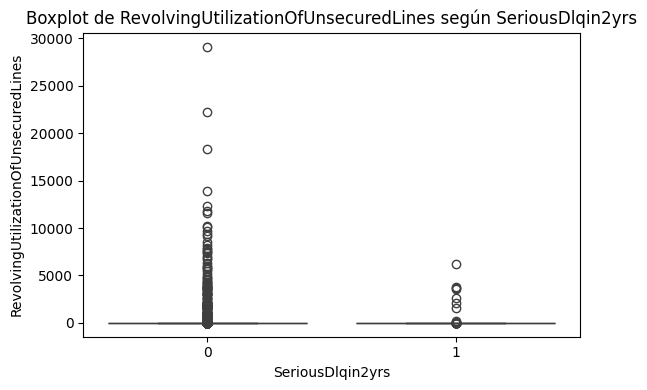

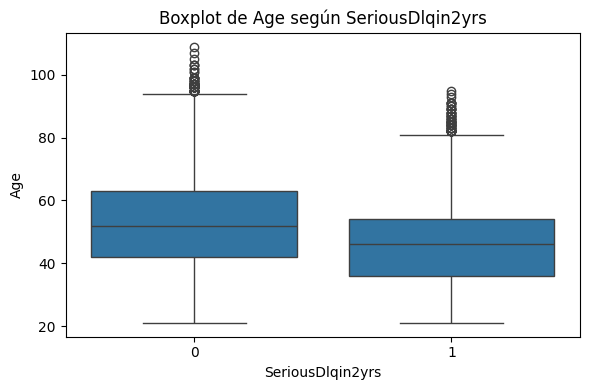

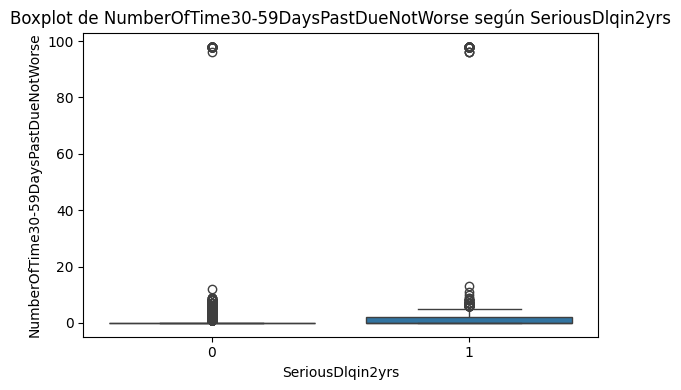

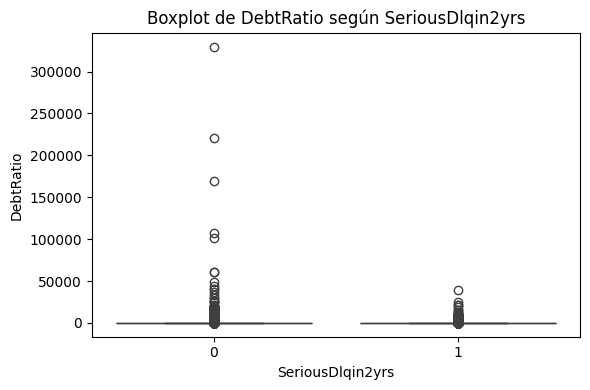

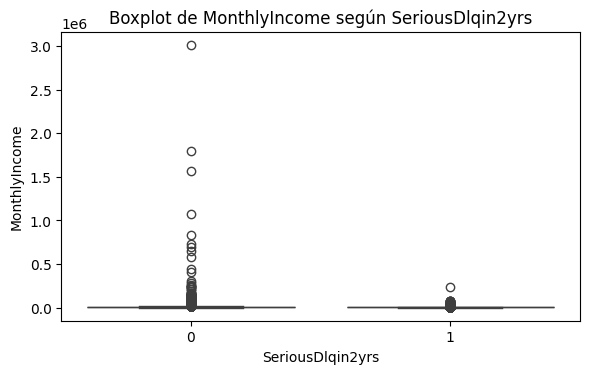

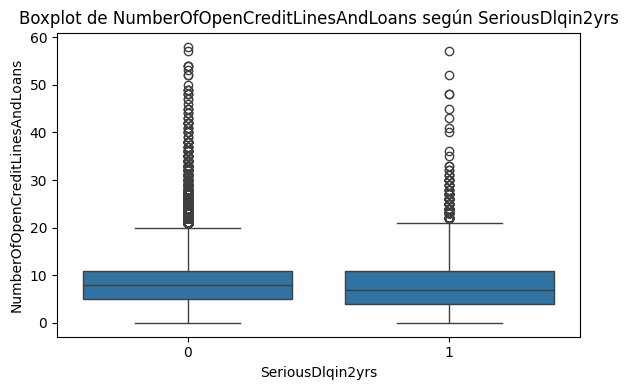

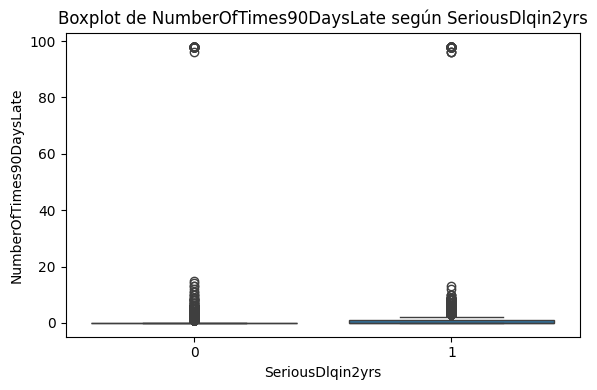

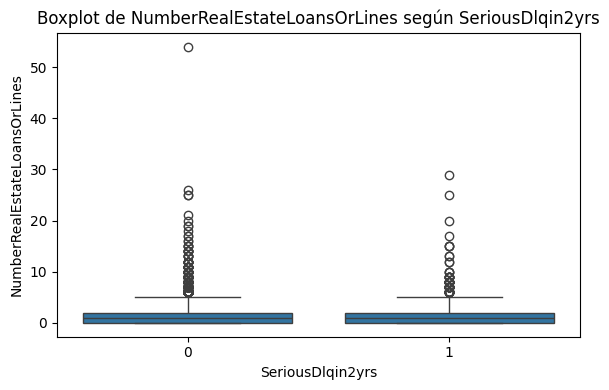

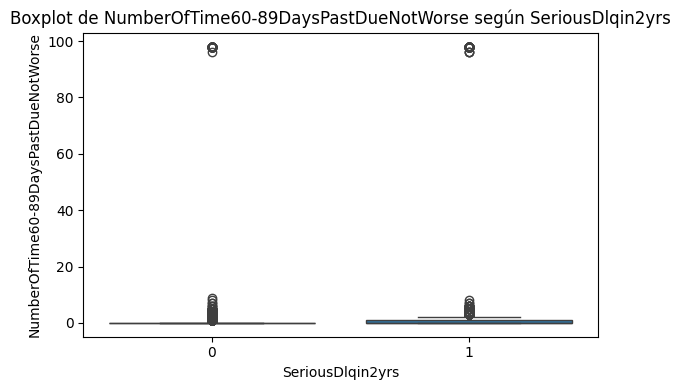

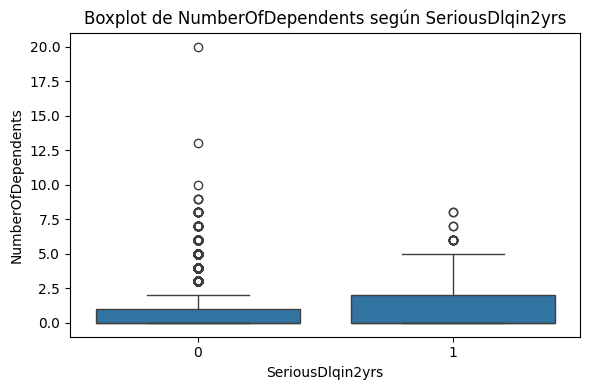

In [32]:
features = [col for col in train.columns if col not in ['ID', 'SeriousDlqin2yrs'] and not col.endswith('_missing')]
for col in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=train, x='SeriousDlqin2yrs', y=col)
    plt.title(f'Boxplot de {col} según SeriousDlqin2yrs')
    plt.tight_layout()
    plt.show()

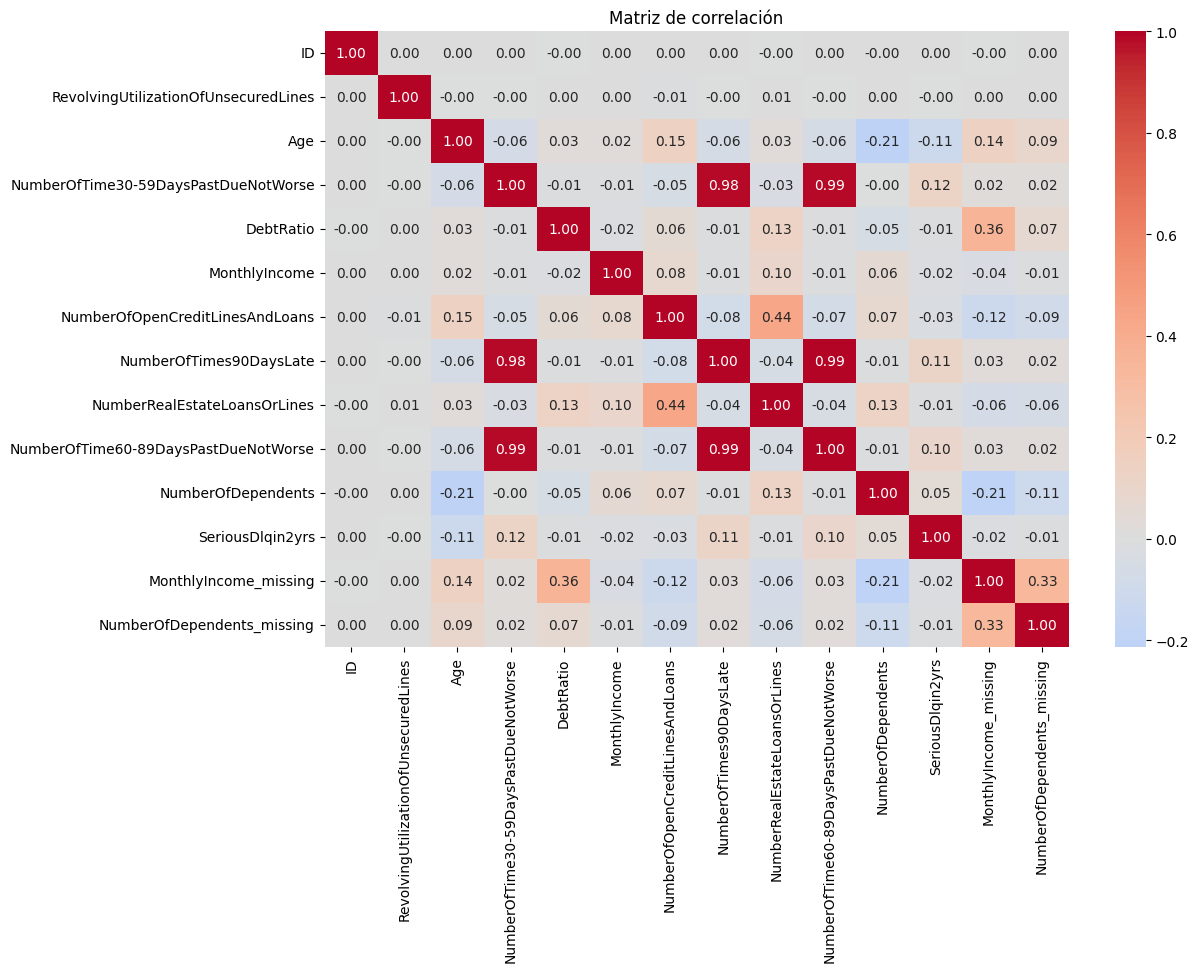

In [33]:
corr_matrix = train.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

In [34]:
X = train.drop(['SeriousDlqin2yrs', 'ID'], axis=1)
y = train['SeriousDlqin2yrs']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict_proba(X_val)[:, 1]

print("AUC (Random Forest):", roc_auc_score(y_val, y_pred_rf))

In [37]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),  # manejar desbalanceo
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict_proba(X_val)[:, 1]

print("AUC (XGBoost):", roc_auc_score(y_val, y_pred_xgb))

c:\Users\jonol\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:14:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC (XGBoost): 0.8580329563306217


In [38]:
from sklearn.model_selection import GridSearchCV



param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'gamma': [0, 1, 5],
}

xgb = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

grid = GridSearchCV(xgb, param_grid, scoring='roc_auc', cv=3, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits


c:\Users\jonol\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:21:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores parámetros: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


In [41]:

best_params = grid.best_params_

xgb_final = XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

xgb_final.fit(X_train, y_train)

test_pred_xgb = xgb_final.predict_proba(test.drop('ID', axis=1))[:, 1]

submission_xgb = pd.DataFrame({
    'ID': test['ID'],
    'SeriousDlqin2yrs': test_pred_xgb
})
submission_xgb.to_csv('submission_xgb.csv', index=False)

c:\Users\jonol\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:21:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [42]:
test_pred_rf = rf.predict_proba(test.drop('ID', axis=1))[:, 1]

submission_rf = pd.DataFrame({
    'ID': test['ID'],
    'SeriousDlqin2yrs': test_pred_rf
})

submission_rf.to_csv('submissionpasta_rf.csv', index=False)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

grid_rf = GridSearchCV(
    rf,
    param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros RF:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict_proba(X_val)[:, 1]
print("AUC (Random Forest optimizado):", roc_auc_score(y_val, y_pred_rf))


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Mejores parámetros RF: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
AUC (Random Forest optimizado): 0.8558763137615965


In [ ]:
best_rf = grid_rf.best_estimator_

test_pred_rf = best_rf.predict_proba(test.drop('ID', axis=1))[:, 1]

submission_rf = pd.DataFrame({
    'ID': test['ID'],
    'SeriousDlqin2yrs': test_pred_rf
})

submission_rf.to_csv('submissionpasta_rf_2.csv', index=False)
